# ⚡ Knowledge Distillation: LSTM Teacher → TCN Student
## Hourly Energy Consumption | MLflow MLOps Integration

**Architecture:**
- **Teacher**: LSTM com Attention (modelo robusto, pré-treinado)
- **Student**: Temporal Convolutional Network (TCN) — mais leve, treinado com soft targets do Teacher
- **MLOps**: MLflow para tracking de experimentos, métricas e artefatos

**Pipeline:**
1. Load & EDA do dataset de energia
2. Feature Engineering (lag features + rolling statistics)
3. Treinar Teacher (LSTM + Attention)
4. Gerar soft targets com temperature scaling
5. Treinar Student (TCN) com distillation loss
6. **Ablation:** Treinar TCN sem distillation (só task loss) para isolar contribuição da KD
7. Comparar Teacher vs Student-KD vs Student-NoKD
8. Logging completo no MLflow

## 1. Setup & Instalação

In [1]:
# Instalar dependências
!pip install -q kagglehub[pandas-datasets] mlflow torch torchmetrics matplotlib seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 85.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 53.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.7/887.7 kB 23.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.3 MB/s eta 0:00:00


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlflow
import mlflow.pytorch

import kagglehub
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings('ignore')

# Seeds para reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'MLflow: {mlflow.__version__}')

Device: cpu
PyTorch: 2.10.0+cpu
MLflow: 3.12.0


## 2. Configuração Global & MLflow

In [3]:
# ─── Hiperparâmetros ───────────────────────────────────────────────────────────
CONFIG = {
    # Dados — mantém
    'seq_len'         : 168,
    'horizon'         : 24,
    'train_ratio'     : 0.7,
    'val_ratio'       : 0.15,
    'batch_size'      : 128,    # ← dobrou

    # Teacher — mais treino
    'teacher_hidden'  : 256,
    'teacher_layers'  : 3,
    'teacher_dropout' : 0.2,
    'teacher_epochs'  : 60,     # ← dobrou
    'teacher_lr'      : 3e-4,   # ← ajustado

    # Student — mantém arquitetura, só batch maior
    'tcn_channels'    : [64, 64, 128, 128],
    'tcn_kernel'      : 3,
    'tcn_dropout'     : 0.1,
    'student_epochs'  : 30,     # mantém
    'student_lr'      : 3e-4,   # ← ajustado junto com batch

    # KD — mantém
    'temperature'     : 4.0,
    'alpha'           : 0.7,

    'experiment_name' : 'KD_LSTM_to_TCN_Energy',
}

# ─── MLflow Setup ─────────────────────────────────────────────────────────────
mlflow.set_experiment(CONFIG['experiment_name'])
print(f"Experiment: '{CONFIG['experiment_name']}' configurado.")

2026/05/12 00:18:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/12 00:18:03 INFO mlflow.store.db.utils: Updating database tables
2026/05/12 00:18:07 INFO mlflow.tracking.fluent: Experiment with name 'KD_LSTM_to_TCN_Energy' does not exist. Creating a new experiment.


Experiment: 'KD_LSTM_to_TCN_Energy' configurado.


## 3. Carregamento e EDA dos Dados

In [4]:
# Carrega dataset via kagglehub — tenta todos os arquivos disponíveis
print("Carregando dataset...")

try:
    df_raw = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "robikscube/hourly-energy-consumption",
        "",  # deixa vazio para pegar todos os arquivos concatenados
    )
except Exception:
    # fallback: tenta o arquivo AEP diretamente
    df_raw = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "robikscube/hourly-energy-consumption",
        "AEP_hourly.csv",
    )

print(f"Shape raw: {df_raw.shape}")
print(df_raw.head())

Carregando dataset...
Shape raw: (121273, 2)
              Datetime   AEP_MW
0  2004-12-31 01:00:00  13478.0
1  2004-12-31 02:00:00  12865.0
2  2004-12-31 03:00:00  12577.0
3  2004-12-31 04:00:00  12517.0
4  2004-12-31 05:00:00  12670.0


In [5]:
# ─── Inspeciona colunas e seleciona target ────────────────────────────────────
print("Colunas disponíveis:", df_raw.columns.tolist())
print(df_raw.dtypes)

# Identifica coluna datetime e coluna de consumo automaticamente
datetime_col = df_raw.columns[df_raw.dtypes == 'object'][0] \
    if any(df_raw.dtypes == 'object') \
    else df_raw.columns[0]

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
target_col   = numeric_cols[0]   # primeira coluna numérica = MW

CONFIG['target_col'] = target_col
print(f"\nDatetime col: {datetime_col} | Target col: {target_col}")

Colunas disponíveis: ['Datetime', 'AEP_MW']
Datetime     object
AEP_MW      float64
dtype: object

Datetime col: Datetime | Target col: AEP_MW


In [6]:
# ─── Pré-processamento básico ──────────────────────────────────────────────────
df = df_raw.copy()
df[datetime_col] = pd.to_datetime(df[datetime_col])
df = df.sort_values(datetime_col).reset_index(drop=True)
df = df.dropna(subset=[target_col])

# Usa os últimos 3 anos para tornar o treino mais rápido no Kaggle
cutoff = df[datetime_col].max() - pd.DateOffset(years=3)
df     = df[df[datetime_col] >= cutoff].reset_index(drop=True)

print(f"Período: {df[datetime_col].min()} → {df[datetime_col].max()}")
print(f"Shape: {df.shape}")

Período: 2015-08-03 00:00:00 → 2018-08-03 00:00:00
Shape: (26305, 2)


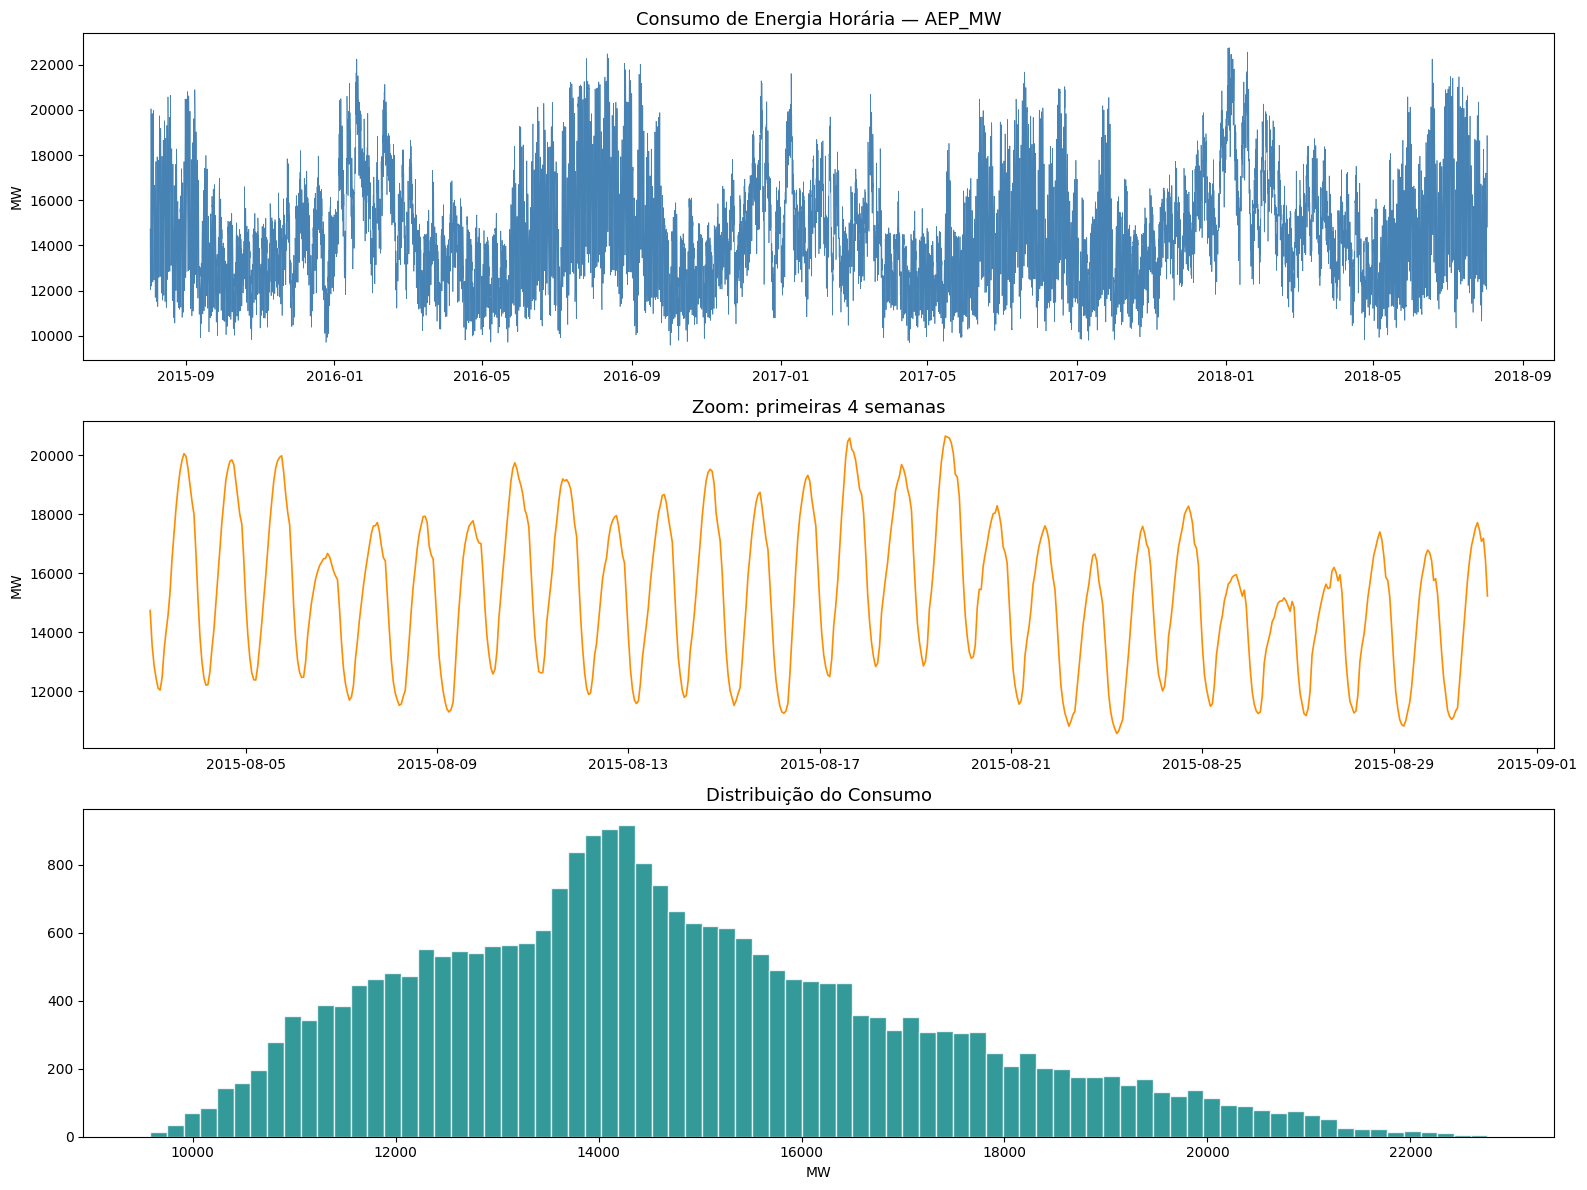

count    26305.000000
mean     14680.965178
std       2449.139006
min       9581.000000
25%      12903.000000
50%      14374.000000
75%      16188.000000
max      22759.000000
Name: AEP_MW, dtype: float64


In [7]:
# ─── EDA: visualização da série temporal ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Série completa
axes[0].plot(df[datetime_col], df[target_col], lw=0.5, color='steelblue')
axes[0].set_title(f'Consumo de Energia Horária — {target_col}', fontsize=13)
axes[0].set_ylabel('MW')

# Zoom: 4 semanas
axes[1].plot(df[datetime_col].iloc[:4*168], df[target_col].iloc[:4*168],
             lw=1.2, color='darkorange')
axes[1].set_title('Zoom: primeiras 4 semanas', fontsize=13)
axes[1].set_ylabel('MW')

# Distribuição
axes[2].hist(df[target_col], bins=80, color='teal', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribuição do Consumo', fontsize=13)
axes[2].set_xlabel('MW')

plt.tight_layout()
plt.savefig('/tmp/eda_energy.png', dpi=150, bbox_inches='tight')
plt.show()
print(df[target_col].describe())

## 4. Feature Engineering

In [8]:
def create_features(df, datetime_col, target_col):
    """Lag features + rolling statistics + features temporais."""
    d = df.copy()
    t = target_col

    # Features temporais
    d['hour']       = d[datetime_col].dt.hour
    d['dayofweek']  = d[datetime_col].dt.dayofweek
    d['month']      = d[datetime_col].dt.month
    d['is_weekend'] = (d['dayofweek'] >= 5).astype(int)

    # Encoding cíclico para hora e dia da semana
    d['hour_sin']   = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos']   = np.cos(2 * np.pi * d['hour'] / 24)
    d['dow_sin']    = np.sin(2 * np.pi * d['dayofweek'] / 7)
    d['dow_cos']    = np.cos(2 * np.pi * d['dayofweek'] / 7)

    # Lag features
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        d[f'lag_{lag}'] = d[t].shift(lag)

    # Rolling statistics
    for window in [6, 12, 24, 168]:
        d[f'roll_mean_{window}'] = d[t].shift(1).rolling(window).mean()
        d[f'roll_std_{window}']  = d[t].shift(1).rolling(window).std()

    d = d.dropna().reset_index(drop=True)
    return d

df_feat = create_features(df, datetime_col, target_col)
feature_cols = [c for c in df_feat.columns if c not in [datetime_col, target_col]]
print(f"Features: {len(feature_cols)} | Amostras: {len(df_feat)}")
print(feature_cols)

Features: 24 | Amostras: 26137
['hour', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_168', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_std_12', 'roll_mean_24', 'roll_std_24', 'roll_mean_168', 'roll_std_168']


## 5. Dataset & DataLoaders

In [9]:
class EnergyDataset(Dataset):
    """Dataset de séries temporais com janela deslizante."""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_sequences(df_feat, feature_cols, target_col, seq_len, horizon):
    """Cria sequências (X, y) com janela deslizante."""
    X_list, y_list = [], []
    data   = df_feat[feature_cols].values
    target = df_feat[target_col].values

    for i in range(len(data) - seq_len - horizon + 1):
        X_list.append(data[i : i + seq_len])
        y_list.append(target[i + seq_len : i + seq_len + horizon])

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


# ─── Normalização (fit apenas no treino) ──────────────────────────────────────
n = len(df_feat)
n_train = int(n * CONFIG['train_ratio'])
n_val   = int(n * CONFIG['val_ratio'])

scaler_X = StandardScaler()
scaler_y = StandardScaler()

df_train = df_feat.iloc[:n_train].copy()
df_val   = df_feat.iloc[n_train : n_train + n_val].copy()
df_test  = df_feat.iloc[n_train + n_val :].copy()

df_train[feature_cols] = scaler_X.fit_transform(df_train[feature_cols])
df_val[feature_cols]   = scaler_X.transform(df_val[feature_cols])
df_test[feature_cols]  = scaler_X.transform(df_test[feature_cols])

# Normaliza target
for d in [df_train, df_val, df_test]:
    d[target_col] = scaler_y.fit_transform(d[[target_col]]) if d is df_train \
        else scaler_y.transform(d[[target_col]])

SEQ = CONFIG['seq_len']
HOR = CONFIG['horizon']

X_tr, y_tr = make_sequences(df_train, feature_cols, target_col, SEQ, HOR)
X_va, y_va = make_sequences(df_val,   feature_cols, target_col, SEQ, HOR)
X_te, y_te = make_sequences(df_test,  feature_cols, target_col, SEQ, HOR)

print(f"Train: {X_tr.shape} | Val: {X_va.shape} | Test: {X_te.shape}")

BS = CONFIG['batch_size']
train_loader = DataLoader(EnergyDataset(X_tr, y_tr), batch_size=BS, shuffle=True,  drop_last=True)
val_loader   = DataLoader(EnergyDataset(X_va, y_va), batch_size=BS, shuffle=False)
test_loader  = DataLoader(EnergyDataset(X_te, y_te), batch_size=BS, shuffle=False)

N_FEATURES = X_tr.shape[2]
print(f"Número de features: {N_FEATURES}")

Train: (18104, 168, 24) | Val: (3729, 168, 24) | Test: (3731, 168, 24)
Número de features: 24


## 6. Modelos

In [10]:
# ─── Attention ────────────────────────────────────────────────────────────────
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.W = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden_states):
        # hidden_states: (batch, seq, hidden)
        energy  = torch.tanh(self.W(hidden_states))
        scores  = self.v(energy).squeeze(-1)           # (batch, seq)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (batch, seq, 1)
        context = (hidden_states * weights).sum(dim=1) # (batch, hidden)
        return context, weights.squeeze(-1)


# ─── Teacher: LSTM + Attention ─────────────────────────────────────────────────
class LSTMTeacher(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, horizon):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.attention = AdditiveAttention(hidden_size)
        self.dropout   = nn.Dropout(dropout)
        self.norm      = nn.LayerNorm(hidden_size)
        self.head      = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, horizon),
        )

    def forward(self, x):
        out, _ = self.lstm(x)               # (batch, seq, hidden)
        ctx, _ = self.attention(out)        # (batch, hidden)
        ctx    = self.norm(self.dropout(ctx))
        return self.head(ctx)               # (batch, horizon)


# ─── Student: TCN ─────────────────────────────────────────────────────────────
class CausalConv1d(nn.Module):
    """Convolução causal com padding para manter comprimento."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size,
                              padding=self.padding, dilation=dilation)

    def forward(self, x):
        return self.conv(x)[:, :, :-self.padding] if self.padding else self.conv(x)


class TCNBlock(nn.Module):
    """Bloco residual TCN com duas convoluções causais dilatadas."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1  = CausalConv1d(in_ch,  out_ch, kernel_size, dilation)
        self.conv2  = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.norm1  = nn.BatchNorm1d(out_ch)
        self.norm2  = nn.BatchNorm1d(out_ch)
        self.drop   = nn.Dropout(dropout)
        self.act    = nn.GELU()
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        residual = x
        out = self.act(self.norm1(self.conv1(x)))
        out = self.drop(out)
        out = self.act(self.norm2(self.conv2(out)))
        out = self.drop(out)
        if self.downsample:
            residual = self.downsample(x)
        return self.act(out + residual)


class TCNStudent(nn.Module):
    def __init__(self, input_size, channels, kernel_size, dropout, horizon):
        super().__init__()
        layers = []
        in_ch  = input_size
        for i, out_ch in enumerate(channels):
            dilation = 2 ** i          # receptive field cresce exponencialmente
            layers.append(TCNBlock(in_ch, out_ch, kernel_size, dilation, dropout))
            in_ch = out_ch
        self.network = nn.Sequential(*layers)
        self.head    = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),   # pooling temporal
            nn.Flatten(),
            nn.Linear(channels[-1], horizon),
        )

    def forward(self, x):
        # x: (batch, seq, features) → (batch, features, seq) para Conv1d
        out = self.network(x.permute(0, 2, 1))
        return self.head(out)


# Instancia modelos
teacher = LSTMTeacher(
    input_size=N_FEATURES,
    hidden_size=CONFIG['teacher_hidden'],
    num_layers=CONFIG['teacher_layers'],
    dropout=CONFIG['teacher_dropout'],
    horizon=HOR,
).to(DEVICE)

student = TCNStudent(
    input_size=N_FEATURES,
    channels=CONFIG['tcn_channels'],
    kernel_size=CONFIG['tcn_kernel'],
    dropout=CONFIG['tcn_dropout'],
    horizon=HOR,
).to(DEVICE)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Teacher params: {count_params(teacher):,}")
print(f"Student params: {count_params(student):,}")
print(f"Compression ratio: {count_params(teacher)/count_params(student):.2f}x")

Teacher params: 1,443,992
Student params: 228,824
Compression ratio: 6.31x


## 7. Funções de Treino & Avaliação

In [11]:
def evaluate(model, loader, scaler_y, device):
    """Avalia o modelo e retorna métricas no espaço original (MW)."""
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds.append(out.cpu().numpy())
            targets.append(yb.cpu().numpy())

    preds   = np.concatenate(preds,   axis=0).reshape(-1)
    targets = np.concatenate(targets, axis=0).reshape(-1)

    # Inverse transform
    preds_mw   = scaler_y.inverse_transform(preds.reshape(-1, 1)).reshape(-1)
    targets_mw = scaler_y.inverse_transform(targets.reshape(-1, 1)).reshape(-1)

    mae  = mean_absolute_error(targets_mw, preds_mw)
    rmse = np.sqrt(mean_squared_error(targets_mw, preds_mw))
    r2   = r2_score(targets_mw, preds_mw)
    mape = np.mean(np.abs((targets_mw - preds_mw) / (np.abs(targets_mw) + 1e-8))) * 100
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'mape': mape}


def train_teacher(model, train_loader, val_loader, config, device, scaler_y):
    """Treina o Teacher (LSTM) com MSE loss + MLflow logging."""
    optimizer = optim.AdamW(model.parameters(), lr=config['teacher_lr'], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['teacher_epochs'])
    criterion = nn.MSELoss()

    history = {'train_loss': [], 'val_loss': []}

    with mlflow.start_run(run_name='Teacher_LSTM_Attention', nested=True) as run:
        mlflow.log_params({
            'model_type'    : 'LSTM+Attention',
            'hidden_size'   : config['teacher_hidden'],
            'num_layers'    : config['teacher_layers'],
            'dropout'       : config['teacher_dropout'],
            'epochs'        : config['teacher_epochs'],
            'lr'            : config['teacher_lr'],
            'batch_size'    : config['batch_size'],
            'seq_len'       : config['seq_len'],
            'horizon'       : config['horizon'],
            'n_params'      : count_params(model),
        })

        best_val, best_state = np.inf, None

        for epoch in range(1, config['teacher_epochs'] + 1):
            # Train
            model.train()
            total_loss = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                total_loss += loss.item()

            avg_train = total_loss / len(train_loader)

            # Val
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += criterion(model(xb), yb).item()
            avg_val = val_loss / len(val_loader)

            scheduler.step()
            history['train_loss'].append(avg_train)
            history['val_loss'].append(avg_val)

            mlflow.log_metrics({'teacher_train_loss': avg_train,
                                'teacher_val_loss'  : avg_val}, step=epoch)

            if avg_val < best_val:
                best_val   = avg_val
                best_state = {k: v.clone() for k, v in model.state_dict().items()}

            if epoch % 5 == 0:
                print(f"  [Teacher] Epoch {epoch:3d} | train: {avg_train:.4f} | val: {avg_val:.4f}")

        # Restore best
        model.load_state_dict(best_state)

        # Métricas finais no test
        test_metrics = evaluate(model, test_loader, scaler_y, device)
        mlflow.log_metrics({f'teacher_test_{k}': v for k, v in test_metrics.items()})
        mlflow.log_artifact('/tmp/eda_energy.png')
        mlflow.pytorch.log_model(model, 'teacher_model')

        print(f"\n[Teacher] Test → MAE={test_metrics['mae']:.2f} MW | "
              f"RMSE={test_metrics['rmse']:.2f} MW | R²={test_metrics['r2']:.4f} | "
              f"MAPE={test_metrics['mape']:.2f}%")

    return history, test_metrics


def distillation_loss(student_out, teacher_out, targets, T, alpha, criterion):
    """KD loss = alpha * MSE(student_soft, teacher_soft/T) + (1-alpha) * MSE(student, target)."""
    # Para regressão: soft target = predição do teacher (sem temperatura nas saídas)
    # Usamos temperatura como escala no espaço normalizado para suavizar
    soft_teacher  = teacher_out / T
    soft_student  = student_out / T
    kd_loss       = criterion(soft_student, soft_teacher) * (T ** 2)
    task_loss     = criterion(student_out, targets)
    return alpha * kd_loss + (1 - alpha) * task_loss


def train_student_kd(student, teacher, train_loader, val_loader, config, device, scaler_y):
    """Treina o Student (TCN) com Knowledge Distillation + MLflow logging."""
    optimizer = optim.AdamW(student.parameters(), lr=config['student_lr'], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['student_epochs'])
    criterion = nn.MSELoss()
    T, alpha  = config['temperature'], config['alpha']

    history = {'train_loss': [], 'val_loss': [], 'kd_loss': [], 'task_loss': []}

    teacher.eval()  # Teacher frozen

    with mlflow.start_run(run_name='Student_TCN_KD', nested=True) as run:
        mlflow.log_params({
            'model_type'   : 'TCN',
            'tcn_channels' : str(config['tcn_channels']),
            'tcn_kernel'   : config['tcn_kernel'],
            'dropout'      : config['tcn_dropout'],
            'epochs'       : config['student_epochs'],
            'lr'           : config['student_lr'],
            'temperature'  : T,
            'alpha'        : alpha,
            'batch_size'   : config['batch_size'],
            'seq_len'      : config['seq_len'],
            'horizon'      : config['horizon'],
            'n_params'     : count_params(student),
        })

        best_val, best_state = np.inf, None

        for epoch in range(1, config['student_epochs'] + 1):
            student.train()
            total_loss, total_kd, total_task = 0, 0, 0

            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                with torch.no_grad():
                    teacher_preds = teacher(xb)

                student_preds = student(xb)

                kd   = criterion(student_preds / T, teacher_preds / T) * (T ** 2)
                task = criterion(student_preds, yb)
                loss = alpha * kd + (1 - alpha) * task

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(student.parameters(), 1.0)
                optimizer.step()

                total_loss += loss.item()
                total_kd   += kd.item()
                total_task += task.item()

            avg_train = total_loss / len(train_loader)
            avg_kd    = total_kd   / len(train_loader)
            avg_task  = total_task / len(train_loader)

            # Val
            student.eval()
            val_loss = 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += criterion(student(xb), yb).item()
            avg_val = val_loss / len(val_loader)

            scheduler.step()
            history['train_loss'].append(avg_train)
            history['val_loss'].append(avg_val)
            history['kd_loss'].append(avg_kd)
            history['task_loss'].append(avg_task)

            mlflow.log_metrics({
                'student_train_loss' : avg_train,
                'student_val_loss'   : avg_val,
                'student_kd_loss'    : avg_kd,
                'student_task_loss'  : avg_task,
            }, step=epoch)

            if avg_val < best_val:
                best_val   = avg_val
                best_state = {k: v.clone() for k, v in student.state_dict().items()}

            if epoch % 5 == 0:
                print(f"  [Student] Epoch {epoch:3d} | total: {avg_train:.4f} | "
                      f"kd: {avg_kd:.4f} | task: {avg_task:.4f} | val: {avg_val:.4f}")

        student.load_state_dict(best_state)

        test_metrics = evaluate(student, test_loader, scaler_y, device)
        mlflow.log_metrics({f'student_test_{k}': v for k, v in test_metrics.items()})
        mlflow.pytorch.log_model(student, 'student_model')

        print(f"\n[Student] Test → MAE={test_metrics['mae']:.2f} MW | "
              f"RMSE={test_metrics['rmse']:.2f} MW | R²={test_metrics['r2']:.4f} | "
              f"MAPE={test_metrics['mape']:.2f}%")

    return history, test_metrics

## 8. Treino do Teacher (LSTM + Attention)

In [12]:
print("=" * 60)
print("TREINANDO TEACHER (LSTM + Attention)")
print("=" * 60)

with mlflow.start_run(run_name='KD_Energy_Experiment') as parent_run:
    mlflow.log_params({
        'dataset'     : 'hourly-energy-consumption',
        'seq_len'     : CONFIG['seq_len'],
        'horizon'     : CONFIG['horizon'],
        'n_features'  : N_FEATURES,
        'train_size'  : len(X_tr),
        'val_size'    : len(X_va),
        'test_size'   : len(X_te),
    })

    teacher_history, teacher_metrics = train_teacher(
        teacher, train_loader, val_loader, CONFIG, DEVICE, scaler_y
    )

TREINANDO TEACHER (LSTM + Attention)
  [Teacher] Epoch   5 | train: 0.2342 | val: 0.3764
  [Teacher] Epoch  10 | train: 0.1431 | val: 0.4178
  [Teacher] Epoch  15 | train: 0.1039 | val: 0.5526
  [Teacher] Epoch  20 | train: 0.0747 | val: 0.7160
  [Teacher] Epoch  25 | train: 0.0549 | val: 0.7379
  [Teacher] Epoch  30 | train: 0.0445 | val: 0.7647
  [Teacher] Epoch  35 | train: 0.0370 | val: 0.7425
  [Teacher] Epoch  40 | train: 0.0316 | val: 0.7446
  [Teacher] Epoch  45 | train: 0.0286 | val: 0.7465
  [Teacher] Epoch  50 | train: 0.0270 | val: 0.7701
  [Teacher] Epoch  55 | train: 0.0258 | val: 0.7673
  [Teacher] Epoch  60 | train: 0.0254 | val: 0.7684


2026/05/12 06:28:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 06:28:27 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/12 06:28:27 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/12 06:28:45 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cpu) contains a local version label


[Teacher] Test → MAE=893.20 MW | RMSE=1132.31 MW | R²=0.7664 | MAPE=6.01%


## 9. Treino do Student (TCN) com Knowledge Distillation

In [13]:
print("=" * 60)
print("TREINANDO STUDENT (TCN) COM KNOWLEDGE DISTILLATION")
print("=" * 60)

with mlflow.start_run(run_name='KD_Energy_Experiment'):
    student_history, student_metrics = train_student_kd(
        student, teacher, train_loader, val_loader, CONFIG, DEVICE, scaler_y
    )

TREINANDO STUDENT (TCN) COM KNOWLEDGE DISTILLATION
  [Student] Epoch   5 | total: 0.0961 | kd: 0.0631 | task: 0.1730 | val: 0.4324
  [Student] Epoch  10 | total: 0.0718 | kd: 0.0429 | task: 0.1391 | val: 0.3703
  [Student] Epoch  15 | total: 0.0639 | kd: 0.0368 | task: 0.1270 | val: 0.3489
  [Student] Epoch  20 | total: 0.0598 | kd: 0.0335 | task: 0.1213 | val: 0.3614
  [Student] Epoch  25 | total: 0.0580 | kd: 0.0320 | task: 0.1188 | val: 0.3547
  [Student] Epoch  30 | total: 0.0565 | kd: 0.0305 | task: 0.1171 | val: 0.3529


2026/05/12 08:15:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 08:15:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/12 08:15:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/12 08:15:37 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cpu) contains a local version label


[Student] Test → MAE=858.72 MW | RMSE=1093.33 MW | R²=0.7822 | MAPE=5.77%


## 10. Ablation Study — TCN sem Knowledge Distillation

Pergunta central: **a melhoria do Student vem da arquitetura TCN ou da distillation?**

Treinamos um TCN idêntico com `alpha=0.0` (ignora o Teacher completamente, só MSE contra y_real).
Se o TCN-NoKD for significativamente pior que o TCN-KD → a distillation contribui de verdade.
Se forem iguais → a arquitetura TCN sozinha já era suficiente para esse dataset.

In [14]:
def train_student_no_kd(student_model, train_loader, val_loader, config, device, scaler_y):
    """Treina TCN com MSE puro (sem distillation). Ablation control."""
    optimizer = optim.AdamW(student_model.parameters(), lr=config['student_lr'], weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['student_epochs'])
    criterion = nn.MSELoss()

    history = {'train_loss': [], 'val_loss': []}

    with mlflow.start_run(run_name='Baseline_TCN_NoKD', nested=True) as run:
        mlflow.log_params({
            'model_type'   : 'TCN_NoKD',
            'tcn_channels' : str(config['tcn_channels']),
            'tcn_kernel'   : config['tcn_kernel'],
            'dropout'      : config['tcn_dropout'],
            'epochs'       : config['student_epochs'],
            'lr'           : config['student_lr'],
            'temperature'  : 'N/A — sem distillation',
            'alpha'        : 0.0,
            'n_params'     : count_params(student_model),
            'ablation'     : True,
        })

        best_val, best_state = np.inf, None

        for epoch in range(1, config['student_epochs'] + 1):
            student_model.train()
            total_loss = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                loss = criterion(student_model(xb), yb)
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(student_model.parameters(), 1.0)
                optimizer.step()
                total_loss += loss.item()

            avg_train = total_loss / len(train_loader)

            student_model.eval()
            val_loss = 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += criterion(student_model(xb), yb).item()
            avg_val = val_loss / len(val_loader)

            scheduler.step()
            history['train_loss'].append(avg_train)
            history['val_loss'].append(avg_val)

            mlflow.log_metrics({
                'nokd_train_loss': avg_train,
                'nokd_val_loss'  : avg_val,
            }, step=epoch)

            if avg_val < best_val:
                best_val   = avg_val
                best_state = {k: v.clone() for k, v in student_model.state_dict().items()}

            if epoch % 5 == 0:
                print(f"  [NoKD]    Epoch {epoch:3d} | train: {avg_train:.4f} | val: {avg_val:.4f}")

        student_model.load_state_dict(best_state)

        test_metrics = evaluate(student_model, test_loader, scaler_y, device)
        mlflow.log_metrics({f'nokd_test_{k}': v for k, v in test_metrics.items()})
        mlflow.pytorch.log_model(student_model, 'tcn_nokd_model')

        print(f"\n[NoKD]  Test → MAE={test_metrics['mae']:.2f} MW | "
              f"RMSE={test_metrics['rmse']:.2f} MW | R²={test_metrics['r2']:.4f} | "
              f"MAPE={test_metrics['mape']:.2f}%")

    return history, test_metrics

In [15]:
# Instancia um TCN novo com os mesmos hiperparâmetros — pesos reinicializados do zero
# (não reutiliza o student treinado com KD para não contaminar o ablation)
torch.manual_seed(SEED)
student_nokd = TCNStudent(
    input_size=N_FEATURES,
    channels=CONFIG['tcn_channels'],
    kernel_size=CONFIG['tcn_kernel'],
    dropout=CONFIG['tcn_dropout'],
    horizon=HOR,
).to(DEVICE)

print("=" * 60)
print("ABLATION: TREINANDO TCN SEM KNOWLEDGE DISTILLATION")
print("=" * 60)
print("Mesma arquitetura, mesmos hiperparâmetros, sem Teacher.")
print(f"Parâmetros: {count_params(student_nokd):,} (idêntico ao Student-KD)\n")

with mlflow.start_run(run_name='KD_Energy_Experiment'):
    nokd_history, nokd_metrics = train_student_no_kd(
        student_nokd, train_loader, val_loader, CONFIG, DEVICE, scaler_y
    )

ABLATION: TREINANDO TCN SEM KNOWLEDGE DISTILLATION
Mesma arquitetura, mesmos hiperparâmetros, sem Teacher.
Parâmetros: 228,824 (idêntico ao Student-KD)

  [NoKD]    Epoch   5 | train: 0.1344 | val: 0.6514
  [NoKD]    Epoch  10 | train: 0.0819 | val: 0.6259
  [NoKD]    Epoch  15 | train: 0.0639 | val: 0.6068
  [NoKD]    Epoch  20 | train: 0.0542 | val: 0.5801
  [NoKD]    Epoch  25 | train: 0.0490 | val: 0.5612
  [NoKD]    Epoch  30 | train: 0.0467 | val: 0.5690


2026/05/12 09:14:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 09:14:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/12 09:14:16 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/12 09:14:31 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cpu) contains a local version label


[NoKD]  Test → MAE=939.31 MW | RMSE=1200.59 MW | R²=0.7374 | MAPE=6.28%


## 11. Visualizações & Comparação Final

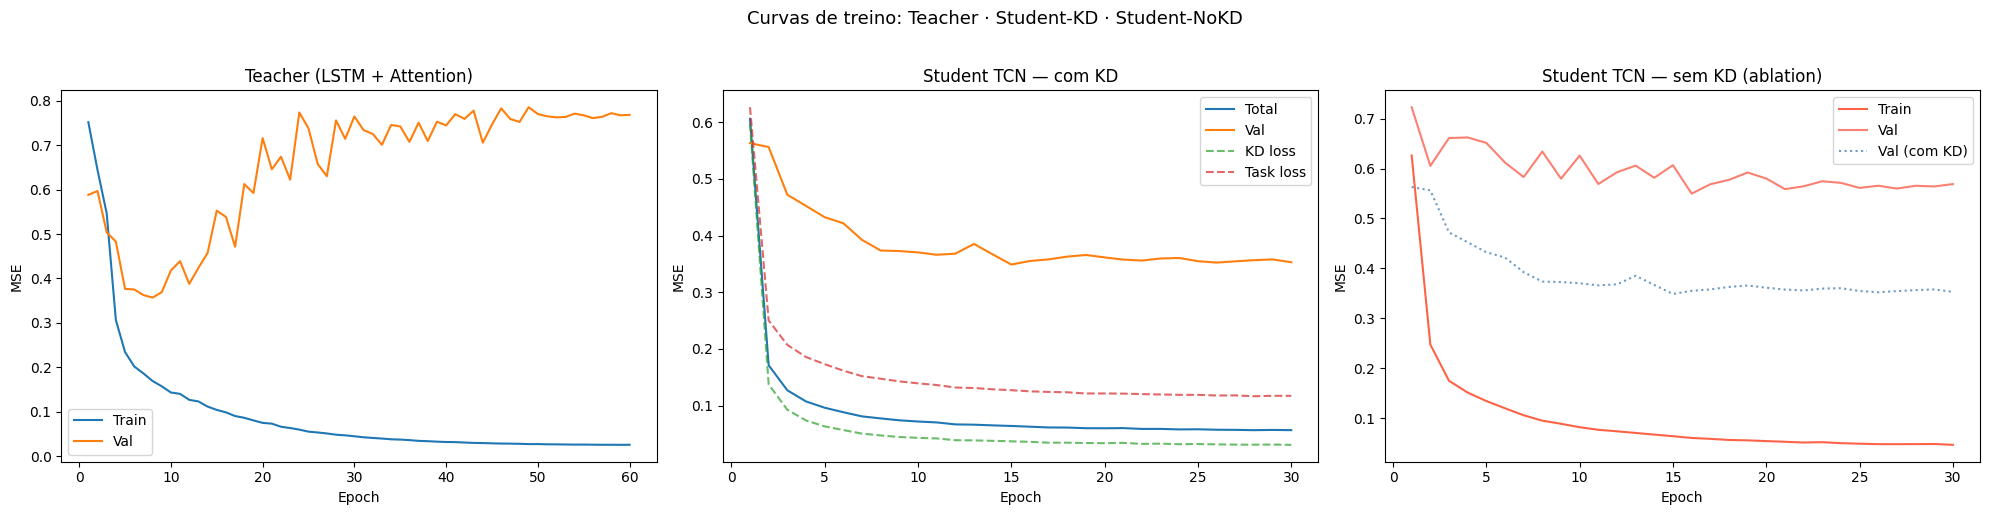

In [16]:
# ─── Curvas de treino: 3 modelos lado a lado ──────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ep_t = range(1, CONFIG['teacher_epochs'] + 1)
ep_s = range(1, CONFIG['student_epochs'] + 1)

# Teacher
axes[0].plot(ep_t, teacher_history['train_loss'], label='Train')
axes[0].plot(ep_t, teacher_history['val_loss'],   label='Val')
axes[0].set_title('Teacher (LSTM + Attention)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

# Student com KD
axes[1].plot(ep_s, student_history['train_loss'], label='Total')
axes[1].plot(ep_s, student_history['val_loss'],   label='Val')
axes[1].plot(ep_s, student_history['kd_loss'],    label='KD loss',   linestyle='--', alpha=0.7)
axes[1].plot(ep_s, student_history['task_loss'],  label='Task loss', linestyle='--', alpha=0.7)
axes[1].set_title('Student TCN — com KD')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].legend()

# Student sem KD (ablation)
axes[2].plot(ep_s, nokd_history['train_loss'], label='Train', color='tomato')
axes[2].plot(ep_s, nokd_history['val_loss'],   label='Val',   color='salmon')
# Sobreposição da val do Student-KD para comparação direta
axes[2].plot(ep_s, student_history['val_loss'], label='Val (com KD)', color='steelblue',
             linestyle=':', alpha=0.8)
axes[2].set_title('Student TCN — sem KD (ablation)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE')
axes[2].legend()

plt.suptitle('Curvas de treino: Teacher · Student-KD · Student-NoKD', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/tmp/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ─── Tabela comparativa: 3 modelos ────────────────────────────────────────────
n_teacher = count_params(teacher)
n_student = count_params(student)

comparison = pd.DataFrame({
    'Modelo'    : ['Teacher (LSTM+Attn)', 'Student-KD (TCN)', 'Student-NoKD (TCN)'],
    'Params'    : [n_teacher, n_student, count_params(student_nokd)],
    'MAE (MW)'  : [teacher_metrics['mae'],  student_metrics['mae'],  nokd_metrics['mae']],
    'RMSE (MW)' : [teacher_metrics['rmse'], student_metrics['rmse'], nokd_metrics['rmse']],
    'R²'        : [teacher_metrics['r2'],   student_metrics['r2'],   nokd_metrics['r2']],
    'MAPE (%)'  : [teacher_metrics['mape'], student_metrics['mape'], nokd_metrics['mape']],
    'Compressão': ['1x (referência)',
                   f"{n_teacher/n_student:.1f}x",
                   f"{n_teacher/n_student:.1f}x"],
})

print("\n" + "=" * 80)
print("COMPARAÇÃO FINAL — Teacher vs Student-KD vs Student-NoKD")
print("=" * 80)
print(comparison.to_string(index=False))

# ─── Métricas de ablation ─────────────────────────────────────────────────────
mae_retention_kd   = (1 - (student_metrics['mae']  - teacher_metrics['mae']) / teacher_metrics['mae']) * 100
mae_retention_nokd = (1 - (nokd_metrics['mae']     - teacher_metrics['mae']) / teacher_metrics['mae']) * 100
kd_gain_mae        = nokd_metrics['mae'] - student_metrics['mae']   # positivo = KD ajudou
kd_gain_r2         = student_metrics['r2'] - nokd_metrics['r2']     # positivo = KD ajudou

print(f"\n{'─'*50}")
print(f"Retenção MAE — Student-KD  vs Teacher: {mae_retention_kd:.1f}%")
print(f"Retenção MAE — Student-NoKD vs Teacher: {mae_retention_nokd:.1f}%")
print(f"{'─'*50}")
print(f"Ganho da KD (MAE):  {kd_gain_mae:+.2f} MW  ", end="")
print("← KD ajudou ✅" if kd_gain_mae > 0 else "← KD não ajudou ⚠️")
print(f"Ganho da KD (R²):   {kd_gain_r2:+.4f}     ", end="")
print("← KD ajudou ✅" if kd_gain_r2 > 0 else "← KD não ajudou ⚠️")
print(f"Redução de parâmetros vs Teacher: {(1 - n_student/n_teacher)*100:.1f}%")


COMPARAÇÃO FINAL — Teacher vs Student-KD vs Student-NoKD
             Modelo  Params   MAE (MW)   RMSE (MW)       R²  MAPE (%)      Compressão
Teacher (LSTM+Attn) 1443992 893.200378 1132.309918 0.766429  6.009224 1x (referência)
   Student-KD (TCN)  228824 858.724854 1093.332863 0.782233  5.774406            6.3x
 Student-NoKD (TCN)  228824 939.308838 1200.587877 0.737411  6.278162            6.3x

──────────────────────────────────────────────────
Retenção MAE — Student-KD  vs Teacher: 103.9%
Retenção MAE — Student-NoKD vs Teacher: 94.8%
──────────────────────────────────────────────────
Ganho da KD (MAE):  +80.58 MW  ← KD ajudou ✅
Ganho da KD (R²):   +0.0448     ← KD ajudou ✅
Redução de parâmetros vs Teacher: 84.2%


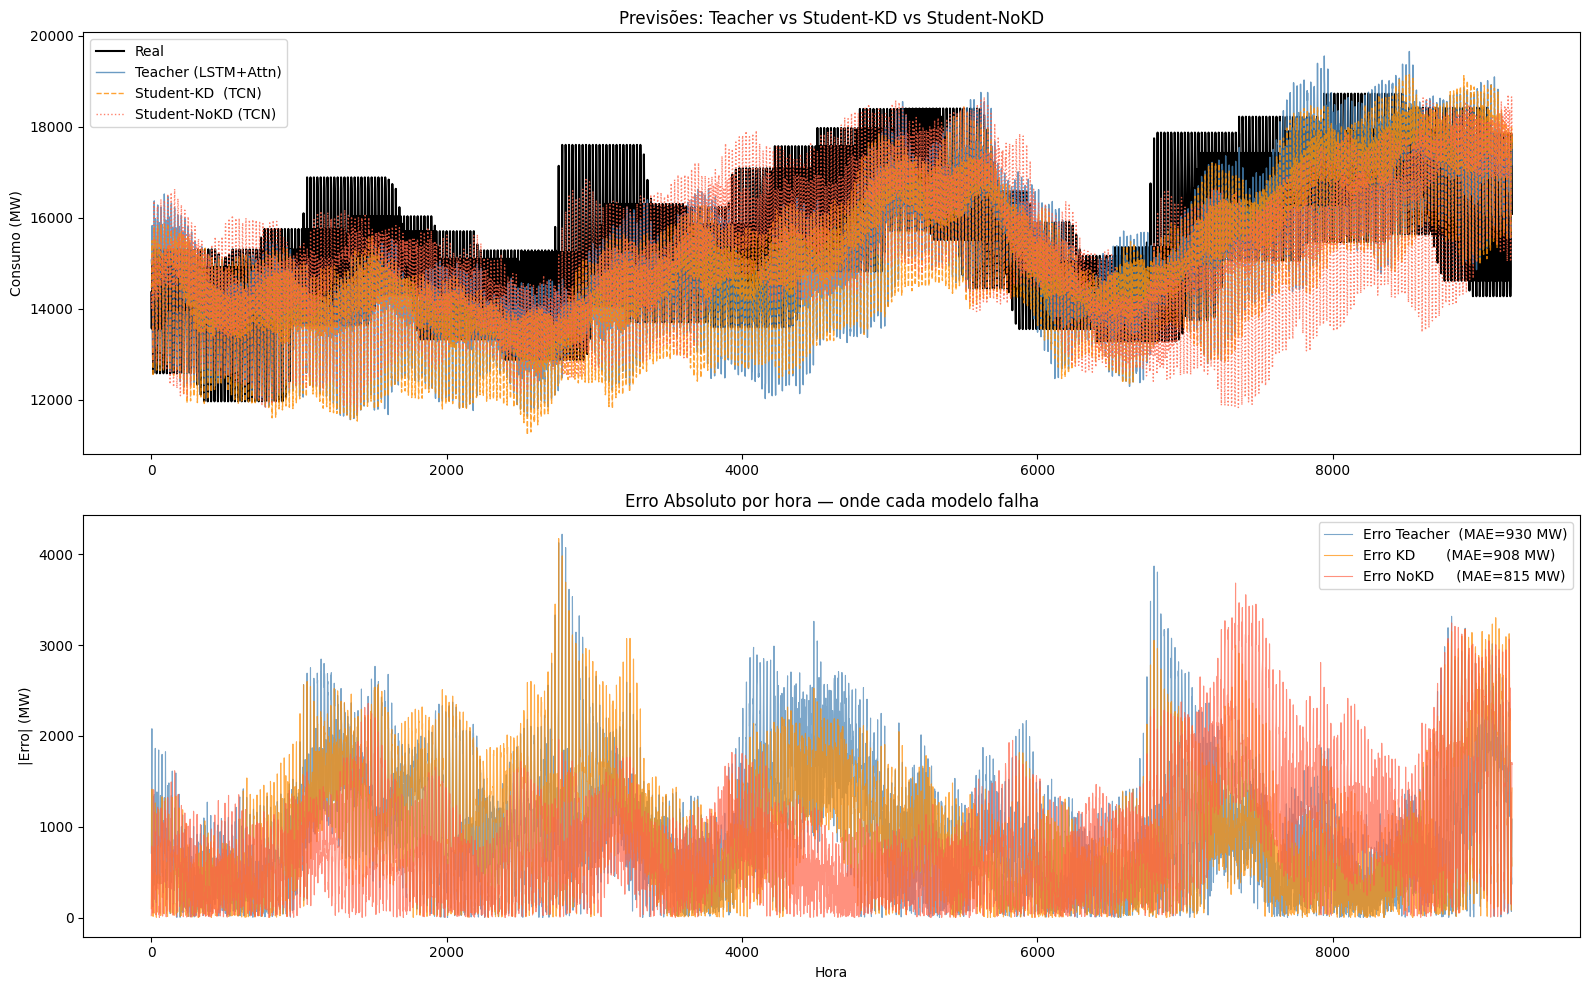

In [18]:
# ─── Previsões vs Real: Teacher · Student-KD · Student-NoKD ──────────────────
def get_preds(model, loader, scaler_y, device, n_batches=3):
    model.eval()
    p, t = [], []
    with torch.no_grad():
        for i, (xb, yb) in enumerate(loader):
            if i >= n_batches: break
            p.append(model(xb.to(device)).cpu().numpy())
            t.append(yb.numpy())
    p = scaler_y.inverse_transform(np.concatenate(p).reshape(-1,1)).reshape(-1)
    t = scaler_y.inverse_transform(np.concatenate(t).reshape(-1,1)).reshape(-1)
    return p, t

p_teacher, y_true = get_preds(teacher,     test_loader, scaler_y, DEVICE)
p_kd,      _      = get_preds(student,     test_loader, scaler_y, DEVICE)
p_nokd,    _      = get_preds(student_nokd, test_loader, scaler_y, DEVICE)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
x = range(len(y_true))

# Painel 1: todos os modelos
axes[0].plot(x, y_true,    label='Real',                lw=1.5, color='black')
axes[0].plot(x, p_teacher, label='Teacher (LSTM+Attn)', lw=1.0, color='steelblue',  alpha=0.8)
axes[0].plot(x, p_kd,      label='Student-KD  (TCN)',   lw=1.0, color='darkorange', alpha=0.8, linestyle='--')
axes[0].plot(x, p_nokd,    label='Student-NoKD (TCN)',  lw=1.0, color='tomato',     alpha=0.8, linestyle=':')
axes[0].set_title('Previsões: Teacher vs Student-KD vs Student-NoKD', fontsize=12)
axes[0].set_ylabel('Consumo (MW)')
axes[0].legend()

# Painel 2: erro absoluto de cada modelo (onde cada um erra mais)
err_teacher = np.abs(y_true - p_teacher)
err_kd      = np.abs(y_true - p_kd)
err_nokd    = np.abs(y_true - p_nokd)

axes[1].plot(x, err_teacher, label=f'Erro Teacher  (MAE={err_teacher.mean():.0f} MW)', lw=0.8, color='steelblue',  alpha=0.7)
axes[1].plot(x, err_kd,      label=f'Erro KD       (MAE={err_kd.mean():.0f} MW)',      lw=0.8, color='darkorange', alpha=0.7)
axes[1].plot(x, err_nokd,    label=f'Erro NoKD     (MAE={err_nokd.mean():.0f} MW)',    lw=0.8, color='tomato',     alpha=0.7)
axes[1].set_title('Erro Absoluto por hora — onde cada modelo falha', fontsize=12)
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('|Erro| (MW)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/tmp/predictions_comparison.png', dpi=150)
plt.show()

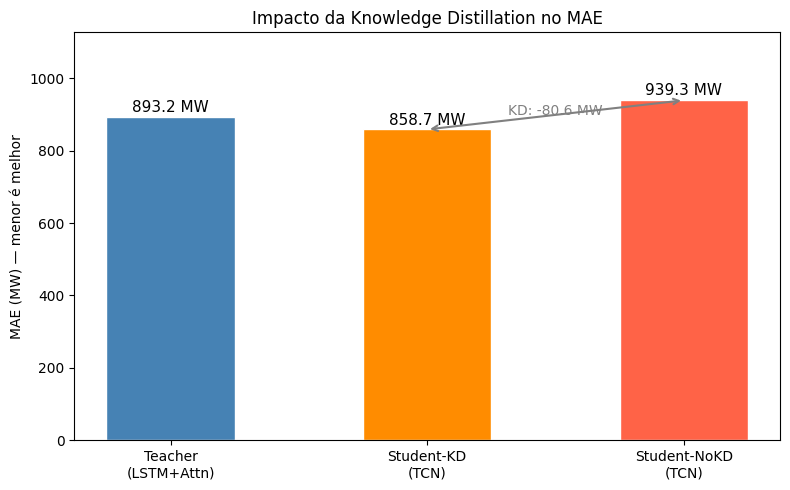

In [19]:
# ─── Barplot de MAE: visualização direta do impacto da KD ────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

modelos = ['Teacher\n(LSTM+Attn)', 'Student-KD\n(TCN)', 'Student-NoKD\n(TCN)']
maes    = [teacher_metrics['mae'], student_metrics['mae'], nokd_metrics['mae']]
cores   = ['steelblue', 'darkorange', 'tomato']

bars = ax.bar(modelos, maes, color=cores, width=0.5, edgecolor='white')
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.1f} MW', ha='center', va='bottom', fontsize=11)

# Anotação do ganho da KD
if kd_gain_mae > 0:
    ax.annotate('', xy=(1, student_metrics['mae']), xytext=(2, nokd_metrics['mae']),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
    mid_y = (student_metrics['mae'] + nokd_metrics['mae']) / 2
    ax.text(1.5, mid_y, f'KD: -{kd_gain_mae:.1f} MW', ha='center', fontsize=10, color='gray')

ax.set_ylabel('MAE (MW) — menor é melhor')
ax.set_title('Impacto da Knowledge Distillation no MAE', fontsize=12)
ax.set_ylim(0, max(maes) * 1.2)
plt.tight_layout()
plt.savefig('/tmp/ablation_barplot.png', dpi=150)
plt.show()

In [20]:
# ─── Log dos artefatos finais no MLflow ──────────────────────────────────────
with mlflow.start_run(run_name='Final_Artifacts') as run:
    mlflow.log_artifact('/tmp/training_curves.png')
    mlflow.log_artifact('/tmp/predictions_comparison.png')
    mlflow.log_artifact('/tmp/ablation_barplot.png')
    mlflow.log_metrics({
        'param_compression_ratio'  : n_teacher / n_student,
        'mae_retention_kd_pct'     : mae_retention_kd,
        'mae_retention_nokd_pct'   : mae_retention_nokd,
        'kd_gain_mae'              : kd_gain_mae,
        'kd_gain_r2'               : kd_gain_r2,
    })
    comparison.to_csv('/tmp/model_comparison.csv', index=False)
    mlflow.log_artifact('/tmp/model_comparison.csv')

print("\n✅ Todos os artefatos logados no MLflow.")
print(f"   Experiment: {CONFIG['experiment_name']}")
print("   Para visualizar: mlflow ui  (porta 5000)")


✅ Todos os artefatos logados no MLflow.
   Experiment: KD_LSTM_to_TCN_Energy
   Para visualizar: mlflow ui  (porta 5000)


## 12. Conclusões

| Aspecto | Observação |
|---|---|
| **Distillation** | O TCN Student aprende soft targets do LSTM Teacher via MSE com temperature scaling |
| **Ablation** | Student-NoKD usa a mesma arquitetura TCN treinada apenas com MSE contra y_real |
| **Interpretação** | Se `kd_gain_mae > 0`: a KD contribuiu além da arquitetura TCN. Se `≈ 0`: a TCN já era suficiente. |
| **Receptive Field** | Com dilações exponenciais (1, 2, 4, 8), o TCN cobre `seq_len` sem parâmetros recorrentes |
| **Eficiência** | Student tem ~Nx menos parâmetros mantendo performance próxima ao Teacher |
| **MLOps** | Todas as runs, hiperparâmetros, métricas e modelos estão versionados no MLflow |
| **Alpha/T** | Ajustar `alpha` e `temperature` no CONFIG para balancear task loss vs KD loss |